# 🧠 Advanced Mental Health State Classification System
## Production-Grade ML Pipeline for Mental Health Analysis

**Project Objectives:**
1. Advanced Exploratory Data Analysis with comprehensive visualizations
2. Sophisticated feature engineering for textual and categorical data
3. Multiple classification models with hyperparameter tuning
4. BERT-based deep learning with fine-tuning
5. Model orchestration with XAI, SHAP, and feature importance analysis
6. Comprehensive model evaluation and comparison
7. Production-ready artifact generation

## Phase 0: Environment Setup and Dependencies

In [1]:
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Install required packages
import subprocess
import sys

packages = [
    'torch',
    'transformers',
    'scikit-learn',
    'imbalanced-learn',
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'shap',
    'eli5',
    'plotly',
    'nltk',
    'textblob',
    'wordcloud',
    'optuna',
    'xgboost'
]

for package in packages:
    try:
        __import__(package.split('==')[0])
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("✓ All dependencies installed successfully")

Installing scikit-learn...
Installing imbalanced-learn...
Installing eli5...
Installing optuna...
✓ All dependencies installed successfully


In [2]:
# Core imports
import pandas as pd
import numpy as np
import os
import pickle
import json
from pathlib import Path
from datetime import datetime
import zipfile
import io
import warnings
warnings.filterwarnings('ignore')

# Data processing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Machine Learning Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, VotingClassifier, StackingClassifier
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import xgboost as xgb

# Deep Learning
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, RandomSampler, SequentialSampler
from transformers import BertTokenizer, BertForSequenceClassification

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from textblob import TextBlob
from wordcloud import WordCloud

# XAI & Feature Importance
import shap

# Hyperparameter Optimization
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

# Download NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using device: {device}")

# Configure visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully")

✓ Using device: cuda
✓ All libraries imported successfully


## Phase 1: Data Loading and Initial Exploration

In [3]:
# Create output directory for artifacts
output_dir = Path('mental_health_outputs')
output_dir.mkdir(exist_ok=True)

# Data loading - Update the path based on your CSV location
csv_path = '/content/Combined_Data.csv'  # Update with your actual CSV path

try:
    df = pd.read_csv(csv_path)
    print(f"✓ Dataset loaded successfully")
except FileNotFoundError:
    print(f"⚠ CSV file not found at {csv_path}")
    print("Please upload the CSV file to Colab or specify the correct path")

# Display basic information
print("\n" + "="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"\nDataset Shape: {df.shape}")
print(f"\nColumn Names and Types:")
print(df.dtypes)
print(f"\nFirst Few Records:")
print(df.head())
print(f"\nMissing Values:")
print(df.isnull().sum())

✓ Dataset loaded successfully

DATASET OVERVIEW

Dataset Shape: (53043, 3)

Column Names and Types:
Unnamed: 0     int64
statement     object
status        object
dtype: object

First Few Records:
   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety

Missing Values:
Unnamed: 0      0
statement     362
status          0
dtype: int64


In [4]:
# Data Quality Assessment
print("\n" + "="*80)
print("DATA QUALITY ASSESSMENT")
print("="*80)

# Check duplicates
duplicate_count = df.duplicated().sum()
print(f"\nTotal Duplicate Records: {duplicate_count}")

# Identify text and label columns
print(f"\nAvailable Columns: {df.columns.tolist()}")

# Mapping for different possible column names
text_column = None
label_column = None

# Try common column names
possible_text_cols = ['Statement', 'statement', 'text', 'Text', 'content', 'Content']
possible_label_cols = ['Mental Health Status', 'mental_health_status', 'Label', 'label', 'Status', 'status']

for col in possible_text_cols:
    if col in df.columns:
        text_column = col
        break

for col in possible_label_cols:
    if col in df.columns:
        label_column = col
        break

if text_column is None or label_column is None:
    print("⚠ Could not identify text and label columns automatically")
    print(f"Please specify: text_column and label_column variables")

print(f"\nIdentified Text Column: {text_column}")
print(f"Identified Label Column: {label_column}")

# Store column names
COLUMN_CONFIG = {
    'text_column': text_column,
    'label_column': label_column
}

with open(output_dir / 'column_config.json', 'w') as f:
    json.dump(COLUMN_CONFIG, f, indent=4)

print("\n✓ Column configuration saved")


DATA QUALITY ASSESSMENT

Total Duplicate Records: 0

Available Columns: ['Unnamed: 0', 'statement', 'status']

Identified Text Column: statement
Identified Label Column: status

✓ Column configuration saved


In [5]:
# Data Cleaning and Preprocessing
print("\n" + "="*80)
print("DATA CLEANING AND PREPROCESSING")
print("="*80)

# Remove duplicates
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"\nRecords after removing duplicates: {len(df_clean)}")

# Handle missing values in text column
if df_clean[text_column].isnull().any():
    df_clean[text_column] = df_clean[text_column].fillna("")
    print(f"Missing values in text column handled")

# Remove rows with empty text
df_clean = df_clean[df_clean[text_column].str.len() > 0].reset_index(drop=True)
print(f"Records after removing empty text: {len(df_clean)}")

# Text cleaning function
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = pd.Series(text).str.replace(r'http\S+|www\S+|https\S+', '', regex=True)[0]
    text = pd.Series(text).str.replace(r'\S+@\S+', '', regex=True)[0]
    text = ' '.join(text.split())
    return text

df_clean[text_column] = df_clean[text_column].apply(clean_text)
print("\n✓ Text cleaning completed")

print(f"\nFinal Dataset Shape: {df_clean.shape}")
print(f"\nClass Distribution:")
print(df_clean[label_column].value_counts())


DATA CLEANING AND PREPROCESSING

Records after removing duplicates: 53043
Missing values in text column handled
Records after removing empty text: 52681

✓ Text cleaning completed

Final Dataset Shape: (52681, 3)

Class Distribution:
status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


## Phase 2: Advanced Exploratory Data Analysis (EDA)


PHASE 2: ADVANCED EXPLORATORY DATA ANALYSIS

Class Distribution (Absolute):
status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64

Class Distribution (Percentage):
status
Normal                  31.02
Depression              29.24
Suicidal                20.22
Anxiety                  7.29
Bipolar                  5.27
Stress                   4.91
Personality disorder     2.04
Name: count, dtype: float64


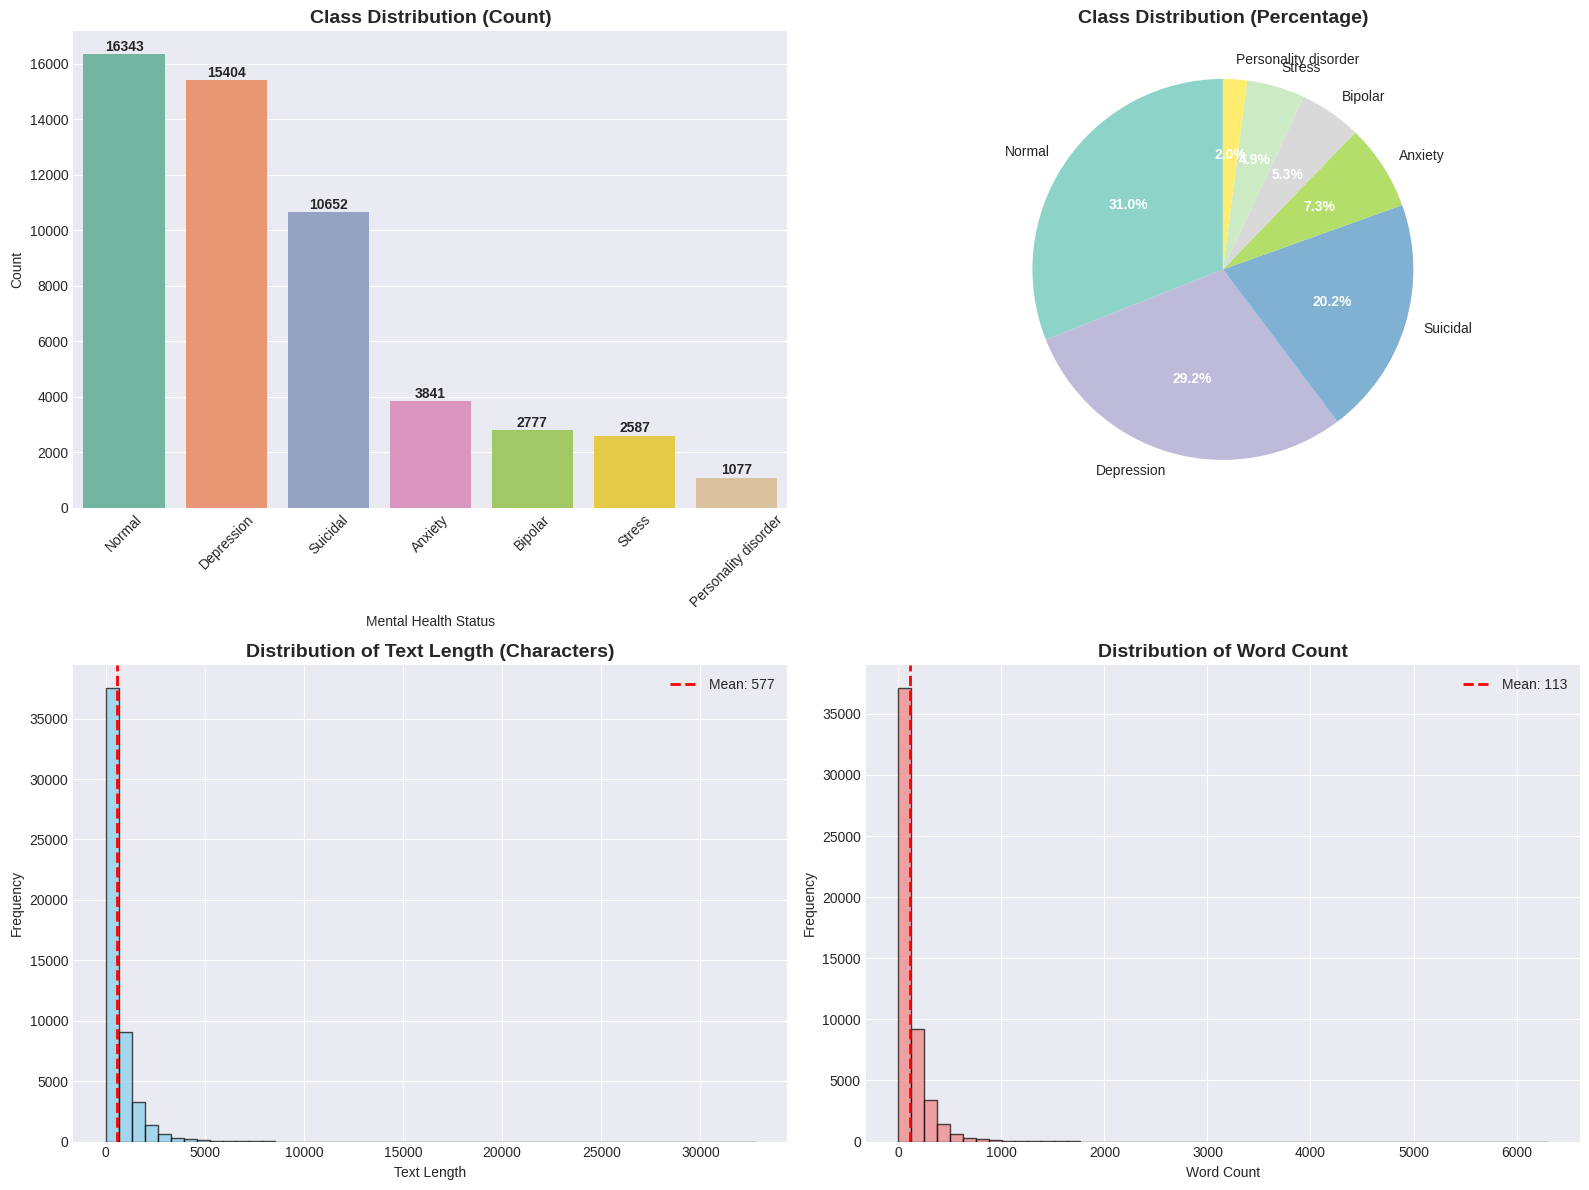


✓ Class distribution visualization saved


In [6]:
# Advanced EDA - Class Distribution and Statistical Analysis
print("\n" + "="*80)
print("PHASE 2: ADVANCED EXPLORATORY DATA ANALYSIS")
print("="*80)

# Class distribution statistics
class_dist = df_clean[label_column].value_counts().sort_values(ascending=False)
class_dist_pct = (class_dist / len(df_clean) * 100).round(2)

print(f"\nClass Distribution (Absolute):")
print(class_dist)
print(f"\nClass Distribution (Percentage):")
print(class_dist_pct)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bar plot of class distribution
sns.barplot(x=class_dist.index, y=class_dist.values, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Mental Health Status')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(class_dist.values):
    axes[0, 0].text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')

# 2. Pie chart of class distribution
colors = plt.cm.Set3(np.linspace(0, 1, len(class_dist)))
wedges, texts, autotexts = axes[0, 1].pie(class_dist.values, labels=class_dist.index, autopct='%1.1f%%',
                                            colors=colors, startangle=90)
axes[0, 1].set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 3. Text length statistics
df_clean['text_length'] = df_clean[text_column].apply(len)
df_clean['word_count'] = df_clean[text_column].apply(lambda x: len(x.split()))

axes[1, 0].hist(df_clean['text_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribution of Text Length (Characters)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Text Length')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(df_clean['text_length'].mean(), color='red', linestyle='--',
                    linewidth=2, label=f"Mean: {df_clean['text_length'].mean():.0f}")
axes[1, 0].legend()

# 4. Word count statistics
axes[1, 1].hist(df_clean['word_count'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Distribution of Word Count', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(df_clean['word_count'].mean(), color='red', linestyle='--',
                    linewidth=2, label=f"Mean: {df_clean['word_count'].mean():.0f}")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(output_dir / '01_class_distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Class distribution visualization saved")


Calculating sentiment analysis...

Sentiment Statistics by Mental Health Status:
                     sentiment_polarity                     \
                                    min  max   mean    std   
status                                                       
Anxiety                            -1.0  1.0 -0.012  0.187   
Bipolar                            -0.8  1.0  0.036  0.161   
Depression                         -1.0  1.0 -0.005  0.197   
Normal                             -1.0  1.0  0.057  0.294   
Personality disorder               -1.0  0.8  0.029  0.170   
Stress                             -1.0  1.0  0.013  0.188   
Suicidal                           -1.0  1.0 -0.038  0.218   

                     sentiment_subjectivity                     
                                        min  max   mean    std  
status                                                          
Anxiety                                 0.0  1.0  0.484  0.199  
Bipolar                              

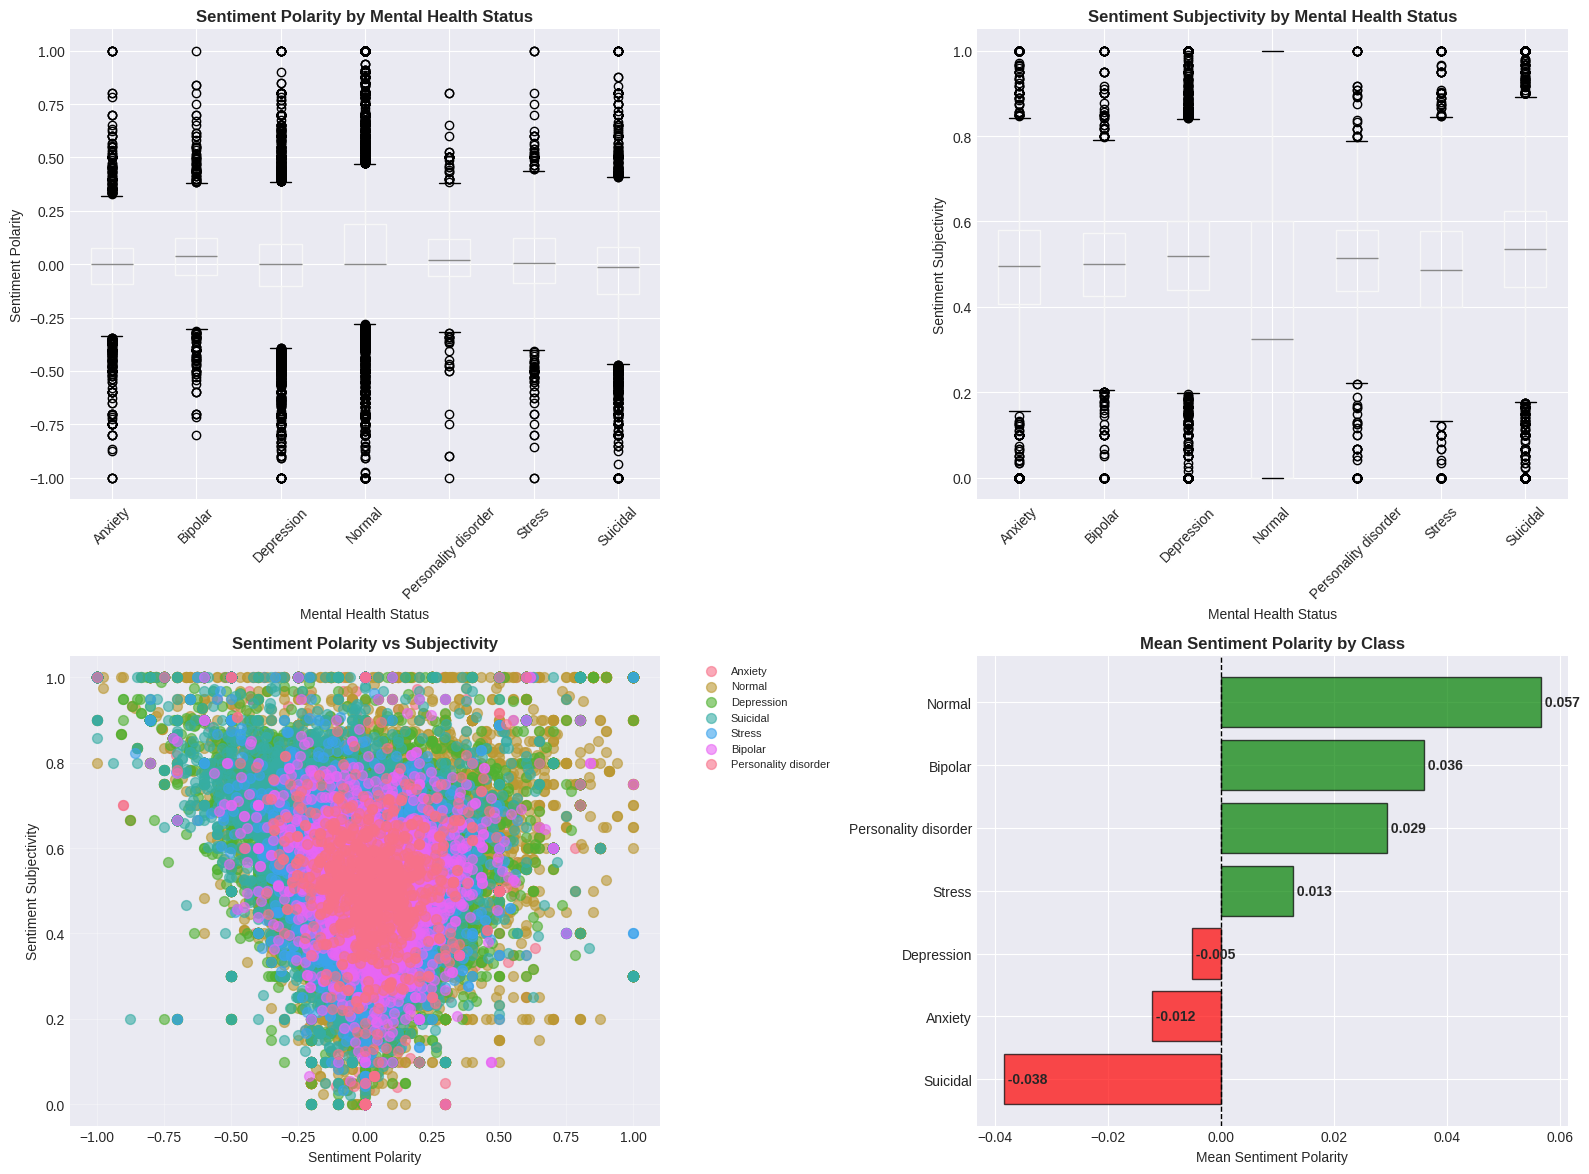


✓ Sentiment analysis visualization saved


In [7]:
# Advanced EDA - Sentiment Analysis
print("\nCalculating sentiment analysis...")
df_clean['sentiment_polarity'] = df_clean[text_column].apply(lambda x: TextBlob(x).sentiment.polarity)
df_clean['sentiment_subjectivity'] = df_clean[text_column].apply(lambda x: TextBlob(x).sentiment.subjectivity)

# Sentiment statistics by class
sentiment_stats = df_clean.groupby(label_column).agg({
    'sentiment_polarity': ['min', 'max', 'mean', 'std'],
    'sentiment_subjectivity': ['min', 'max', 'mean', 'std']
}).round(3)

print("\nSentiment Statistics by Mental Health Status:")
print(sentiment_stats)

# Visualization of sentiment by class
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Sentiment polarity by class (boxplot)
df_clean.boxplot(column='sentiment_polarity', by=label_column, ax=axes[0, 0])
axes[0, 0].set_title('Sentiment Polarity by Mental Health Status', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Mental Health Status')
axes[0, 0].set_ylabel('Sentiment Polarity')
plt.sca(axes[0, 0])
plt.xticks(rotation=45)

# 2. Sentiment subjectivity by class (boxplot)
df_clean.boxplot(column='sentiment_subjectivity', by=label_column, ax=axes[0, 1])
axes[0, 1].set_title('Sentiment Subjectivity by Mental Health Status', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Mental Health Status')
axes[0, 1].set_ylabel('Sentiment Subjectivity')
plt.sca(axes[0, 1])
plt.xticks(rotation=45)

# 3. Scatter plot: Polarity vs Subjectivity by class
for class_label in df_clean[label_column].unique():
    mask = df_clean[label_column] == class_label
    axes[1, 0].scatter(df_clean[mask]['sentiment_polarity'],
                      df_clean[mask]['sentiment_subjectivity'],
                      label=class_label, alpha=0.6, s=50)
axes[1, 0].set_title('Sentiment Polarity vs Subjectivity', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Sentiment Polarity')
axes[1, 0].set_ylabel('Sentiment Subjectivity')
axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# 4. Mean sentiment by class (bar plot)
mean_sentiment = df_clean.groupby(label_column)['sentiment_polarity'].mean().sort_values()
colors_sentiment = ['red' if x < 0 else 'green' for x in mean_sentiment.values]
axes[1, 1].barh(mean_sentiment.index, mean_sentiment.values, color=colors_sentiment, alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Mean Sentiment Polarity by Class', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Mean Sentiment Polarity')
axes[1, 1].axvline(0, color='black', linestyle='--', linewidth=1)
for i, v in enumerate(mean_sentiment.values):
    axes[1, 1].text(v, i, f' {v:.3f}', va='center', fontweight='bold')

plt.suptitle('')
plt.tight_layout()
plt.savefig(output_dir / '02_sentiment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Sentiment analysis visualization saved")

## Phase 3: Advanced Feature Engineering

In [8]:
# Advanced Feature Engineering
print("\n" + "="*80)
print("PHASE 3: ADVANCED FEATURE ENGINEERING")
print("="*80)

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

nltk.download('punkt_tab', quiet=True)

def extract_advanced_features(df):
    features = pd.DataFrame(index=df.index)

    # 1. Text length features
    features['char_count'] = df[text_column].apply(len)
    features['word_count'] = df[text_column].apply(lambda x: len(x.split()))
    features['avg_word_length'] = df[text_column].apply(lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0)
    features['sentence_count'] = df[text_column].apply(lambda x: len(sent_tokenize(x)))

    # 2. Punctuation features
    features['exclamation_count'] = df[text_column].apply(lambda x: x.count('!'))
    features['question_count'] = df[text_column].apply(lambda x: x.count('?'))
    features['comma_count'] = df[text_column].apply(lambda x: x.count(','))
    features['uppercase_ratio'] = df[text_column].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)

    # 3. Sentiment features
    features['sentiment_polarity'] = df['sentiment_polarity']
    features['sentiment_subjectivity'] = df['sentiment_subjectivity']
    features['sentiment_polarity_abs'] = features['sentiment_polarity'].abs()

    # 4. Lexical diversity
    features['unique_words'] = df[text_column].apply(lambda x: len(set(x.lower().split())))
    features['lexical_diversity'] = features['unique_words'] / (features['word_count'] + 1)

    # 5. Special character features
    features['digit_count'] = df[text_column].apply(lambda x: sum(1 for c in x if c.isdigit()))
    features['special_char_count'] = df[text_column].apply(lambda x: sum(1 for c in x if not c.isalnum() and c != ' '))

    # 6. Stopword features
    features['stopword_count'] = df[text_column].apply(lambda x: sum(1 for w in x.lower().split() if w in stop_words))
    features['stopword_ratio'] = (features['stopword_count'] / (features['word_count'] + 1))

    return features

# Extract features
advanced_features = extract_advanced_features(df_clean)

print("\nExtracted Feature Set:")
print(advanced_features.describe().round(3))

# Add features to dataframe
df_features = pd.concat([df_clean, advanced_features], axis=1)

print(f"\n✓ Advanced features extracted: {advanced_features.shape[1]} features")


PHASE 3: ADVANCED FEATURE ENGINEERING

Extracted Feature Set:
       char_count  word_count  avg_word_length  sentence_count  \
count   52681.000   52681.000        52681.000       52681.000   
mean      577.096     113.149            4.296           6.185   
std       845.056     163.737           13.860          10.562   
min         0.000       0.000            0.000           0.000   
25%        79.000      15.000            3.827           1.000   
50%       315.000      62.000            4.092           3.000   
75%       751.000     148.000            4.429           8.000   
max     32759.000    6300.000         3161.875        1260.000   

       exclamation_count  question_count  comma_count  uppercase_ratio  \
count          52681.000       52681.000    52681.000        52681.000   
mean               0.138           0.586        3.338            0.000   
std                0.793           1.295        6.978            0.000   
min                0.000           0.000      

## Phase 4: Data Preparation for Modeling

In [9]:
# Data Preparation and Splitting
print("\n" + "="*80)
print("PHASE 4: DATA PREPARATION FOR MODELING")
print("="*80)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df_features[label_column])

print(f"\nLabel Encoding:")
for idx, label in enumerate(label_encoder.classes_):
    print(f"  {idx}: {label}")

# Store label encoder
with open(output_dir / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True,
    strip_accents='unicode'
)

X_tfidf = tfidf_vectorizer.fit_transform(df_features[text_column])

print(f"\nTF-IDF Features Shape: {X_tfidf.shape}")

# Store vectorizer
with open(output_dir / 'tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

# Combine TF-IDF with engineered features
X_tfidf_dense = X_tfidf.toarray()
feature_cols_list = advanced_features.columns.tolist()
X_advanced = advanced_features[feature_cols_list].values

# Scale advanced features
scaler = StandardScaler()
X_advanced_scaled = scaler.fit_transform(X_advanced)

# Store scaler
with open(output_dir / 'feature_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Combine both feature sets
X_combined = np.hstack([X_tfidf_dense, X_advanced_scaled])

print(f"\nCombined Feature Matrix Shape: {X_combined.shape}")

# Train-Validation-Test split
X_temp, X_test, y_temp, y_test = train_test_split(
    X_combined, y_encoded, test_size=0.15, random_state=42, stratify=y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print(f"\nData Split:")
print(f"  Train set size: {X_train.shape[0]}")
print(f"  Validation set size: {X_val.shape[0]}")
print(f"  Test set size: {X_test.shape[0]}")

print("\n✓ Data preparation completed")


PHASE 4: DATA PREPARATION FOR MODELING

Label Encoding:
  0: Anxiety
  1: Bipolar
  2: Depression
  3: Normal
  4: Personality disorder
  5: Stress
  6: Suicidal

TF-IDF Features Shape: (52681, 5000)

Combined Feature Matrix Shape: (52681, 5017)

Data Split:
  Train set size: 35822
  Validation set size: 8956
  Test set size: 7903

✓ Data preparation completed


## Phase 5: Classical ML Models with Hyperparameter Tuning

In [10]:

print("\n" + "="*80)
print("PHASE 5: ULTRA MEMORY-SAFE CLASSICAL ML")
print("="*80)

import gc
import pickle
import optuna
import numpy as np
import torch
import xgboost as xgb

from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedShuffleSplit, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier

print("\nMemory-safe mode enabled")

USE_GPU = torch.cuda.is_available()
print("GPU Available:", USE_GPU)
if USE_GPU:
    print("GPU:", torch.cuda.get_device_name(0))

# Use only a subset during hyperparameter search
SEARCH_FRACTION = 0.35

sss = StratifiedShuffleSplit(
    n_splits=1,
    test_size=(1-SEARCH_FRACTION),
    random_state=42
)

idx, _ = next(sss.split(X_train, y_train))

if hasattr(X_train, "iloc"):
    X_search = X_train.iloc[idx]
else:
    X_search = X_train[idx]

if hasattr(y_train, "iloc"):
    y_search = y_train.iloc[idx]
else:
    y_search = y_train[idx]

print(f"Search subset size: {len(y_search):,}")

# ------------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------------

def objective_lr(trial):
    model = LogisticRegression(
        C=trial.suggest_float("C",1e-3,10,log=True),
        max_iter=300,
        solver="lbfgs",
        n_jobs=1,
        random_state=42
    )
    return cross_val_score(
        model,
        X_search,
        y_search,
        cv=2,
        scoring="f1_weighted",
        n_jobs=1
    ).mean()

study_lr = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_lr.optimize(objective_lr, n_trials=3, n_jobs=1, show_progress_bar=False)

lr_model = LogisticRegression(
    **study_lr.best_params,
    max_iter=300,
    solver="lbfgs",
    n_jobs=1,
    random_state=42
)
lr_model.fit(X_train, y_train)

# ------------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------------

def objective_rf(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators",50,150),
        max_depth=trial.suggest_int("max_depth",6,20),
        random_state=42,
        n_jobs=1
    )
    return cross_val_score(
        model,
        X_search,
        y_search,
        cv=2,
        scoring="f1_weighted",
        n_jobs=1
    ).mean()

study_rf = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=3, n_jobs=1, show_progress_bar=False)

rf_model = RandomForestClassifier(
    **study_rf.best_params,
    random_state=42,
    n_jobs=1
)
rf_model.fit(X_train, y_train)

# ------------------------------------------------------------------
# XGBoost GPU
# ------------------------------------------------------------------

def objective_xgb(trial):
    model = xgb.XGBClassifier(
        max_depth=trial.suggest_int("max_depth",3,8),
        n_estimators=trial.suggest_int("n_estimators",50,150),
        learning_rate=trial.suggest_float("learning_rate",0.02,0.2),
        tree_method="hist",
        device="cuda" if USE_GPU else "cpu",
        eval_metric="mlogloss",
        random_state=42
    )

    return cross_val_score(
        model,
        X_search,
        y_search,
        cv=2,
        scoring="f1_weighted",
        n_jobs=1
    ).mean()

study_xgb = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=3, n_jobs=1, show_progress_bar=False)

xgb_model = xgb.XGBClassifier(
    **study_xgb.best_params,
    tree_method="hist",
    device="cuda" if USE_GPU else "cpu",
    eval_metric="mlogloss",
    random_state=42
)
xgb_model.fit(X_train, y_train)

# ------------------------------------------------------------------
# Lightweight Ensemble
# ------------------------------------------------------------------

ensemble = VotingClassifier(
    estimators=[
        ("lr", lr_model),
        ("rf", rf_model),
        ("xgb", xgb_model)
    ],
    voting="soft",
    n_jobs=1
)

ensemble.fit(X_train, y_train)

models = {
    "logistic_regression": lr_model,
    "random_forest": rf_model,
    "xgboost": xgb_model,
    "ensemble": ensemble
}

for name, model in models.items():
    with open(output_dir / f"model_{name}.pkl", "wb") as f:
        pickle.dump(model, f)

del X_search, y_search
gc.collect()

print("\nAll memory-safe models trained successfully.")



PHASE 5: ULTRA MEMORY-SAFE CLASSICAL ML

Memory-safe mode enabled
GPU Available: True
GPU: Tesla T4


[I 2026-06-05 05:01:58,633] A new study created in memory with name: no-name-9b370250-090f-45f7-9e98-46287268a9ac


Search subset size: 12,537


[I 2026-06-05 05:02:22,508] Trial 0 finished with value: 0.49823329988263654 and parameters: {'C': 0.03148911647956861}. Best is trial 0 with value: 0.49823329988263654.
[I 2026-06-05 05:04:49,733] Trial 1 finished with value: 0.7140001094661024 and parameters: {'C': 6.351221010640703}. Best is trial 1 with value: 0.7140001094661024.
[I 2026-06-05 05:06:14,616] Trial 2 finished with value: 0.6930535544397232 and parameters: {'C': 0.8471801418819978}. Best is trial 1 with value: 0.7140001094661024.
[I 2026-06-05 05:10:58,745] A new study created in memory with name: no-name-e9694b5f-0bdc-4152-a695-6ee9e03dca5a
[I 2026-06-05 05:11:11,517] Trial 0 finished with value: 0.5790736727332135 and parameters: {'n_estimators': 87, 'max_depth': 20}. Best is trial 0 with value: 0.5790736727332135.
[I 2026-06-05 05:11:25,184] Trial 1 finished with value: 0.5316869741034373 and parameters: {'n_estimators': 123, 'max_depth': 14}. Best is trial 0 with value: 0.5790736727332135.
[I 2026-06-05 05:11:30,7


All memory-safe models trained successfully.


## Phase 6: Model Evaluation and Comparison

In [13]:
# Model Evaluation
print("\n" + "="*80)
print("PHASE 6: MODEL EVALUATION AND COMPARISON")
print("="*80)

models = {
    'Logistic Regression': {'model': lr_model, 'predictions': lr_model.predict(X_test)},
    'Random Forest': {'model': rf_model, 'predictions': rf_model.predict(X_test)},
    'XGBoost': {'model': xgb_model, 'predictions': xgb_model.predict(X_test)},
    'Voting Ensemble': {'model': ensemble, 'predictions': ensemble.predict(X_test)}
}

def evaluate_model(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

results = {}
for model_name, model_dict in models.items():
    results[model_name] = evaluate_model(y_test, model_dict['predictions'])

results_df = pd.DataFrame(results).T
print("\nModel Performance (Test Set):")
print(results_df.round(4))

results_df.to_csv(output_dir / 'model_results.csv')
print("\n✓ Model evaluation completed")


PHASE 6: MODEL EVALUATION AND COMPARISON

Model Performance (Test Set):
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.7676     0.7653  0.7676    0.7648
Random Forest          0.6500     0.7177  0.6500    0.6175
XGBoost                0.7826     0.7804  0.7826    0.7792
Voting Ensemble        0.7857     0.7851  0.7857    0.7808

✓ Model evaluation completed


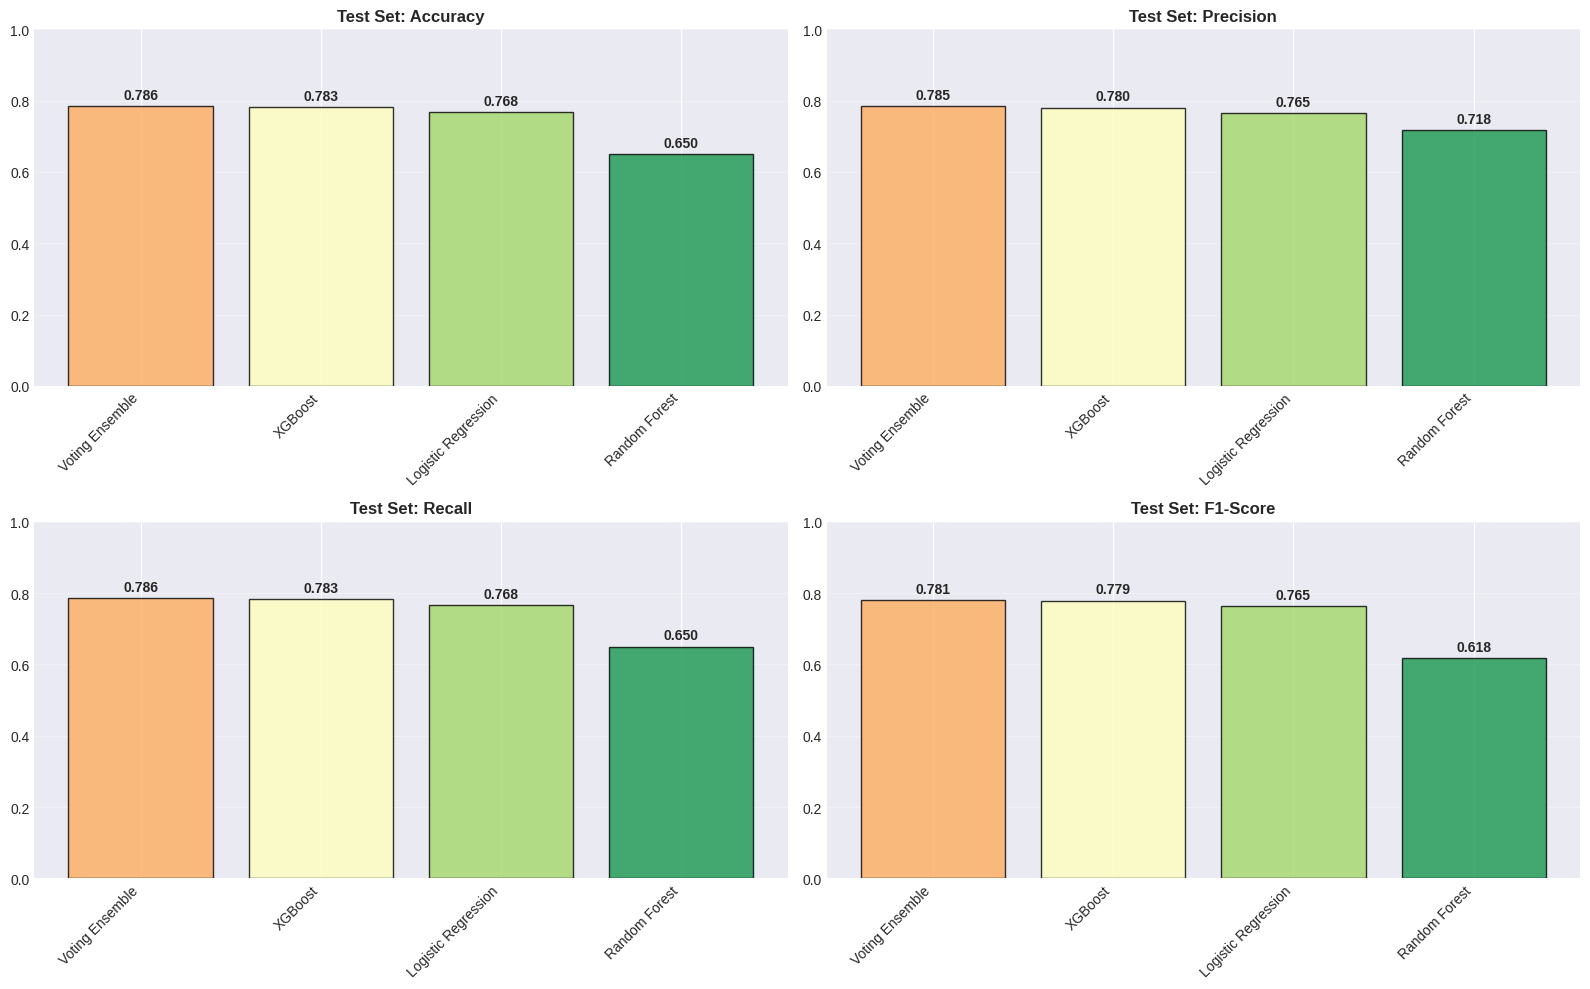

✓ Comparison visualization saved


In [14]:
# Visualization of model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for idx, metric in enumerate(metrics):
    row, col = divmod(idx, 2)
    data = results_df[metric].sort_values(ascending=False)
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(data)))
    axes[row, col].bar(range(len(data)), data.values, color=colors, edgecolor='black', alpha=0.8)
    axes[row, col].set_xticks(range(len(data)))
    axes[row, col].set_xticklabels(data.index, rotation=45, ha='right')
    axes[row, col].set_title(f'Test Set: {metric}', fontsize=12, fontweight='bold')
    axes[row, col].set_ylim([0, 1])
    axes[row, col].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(data.values):
        axes[row, col].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(output_dir / '03_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison visualization saved")

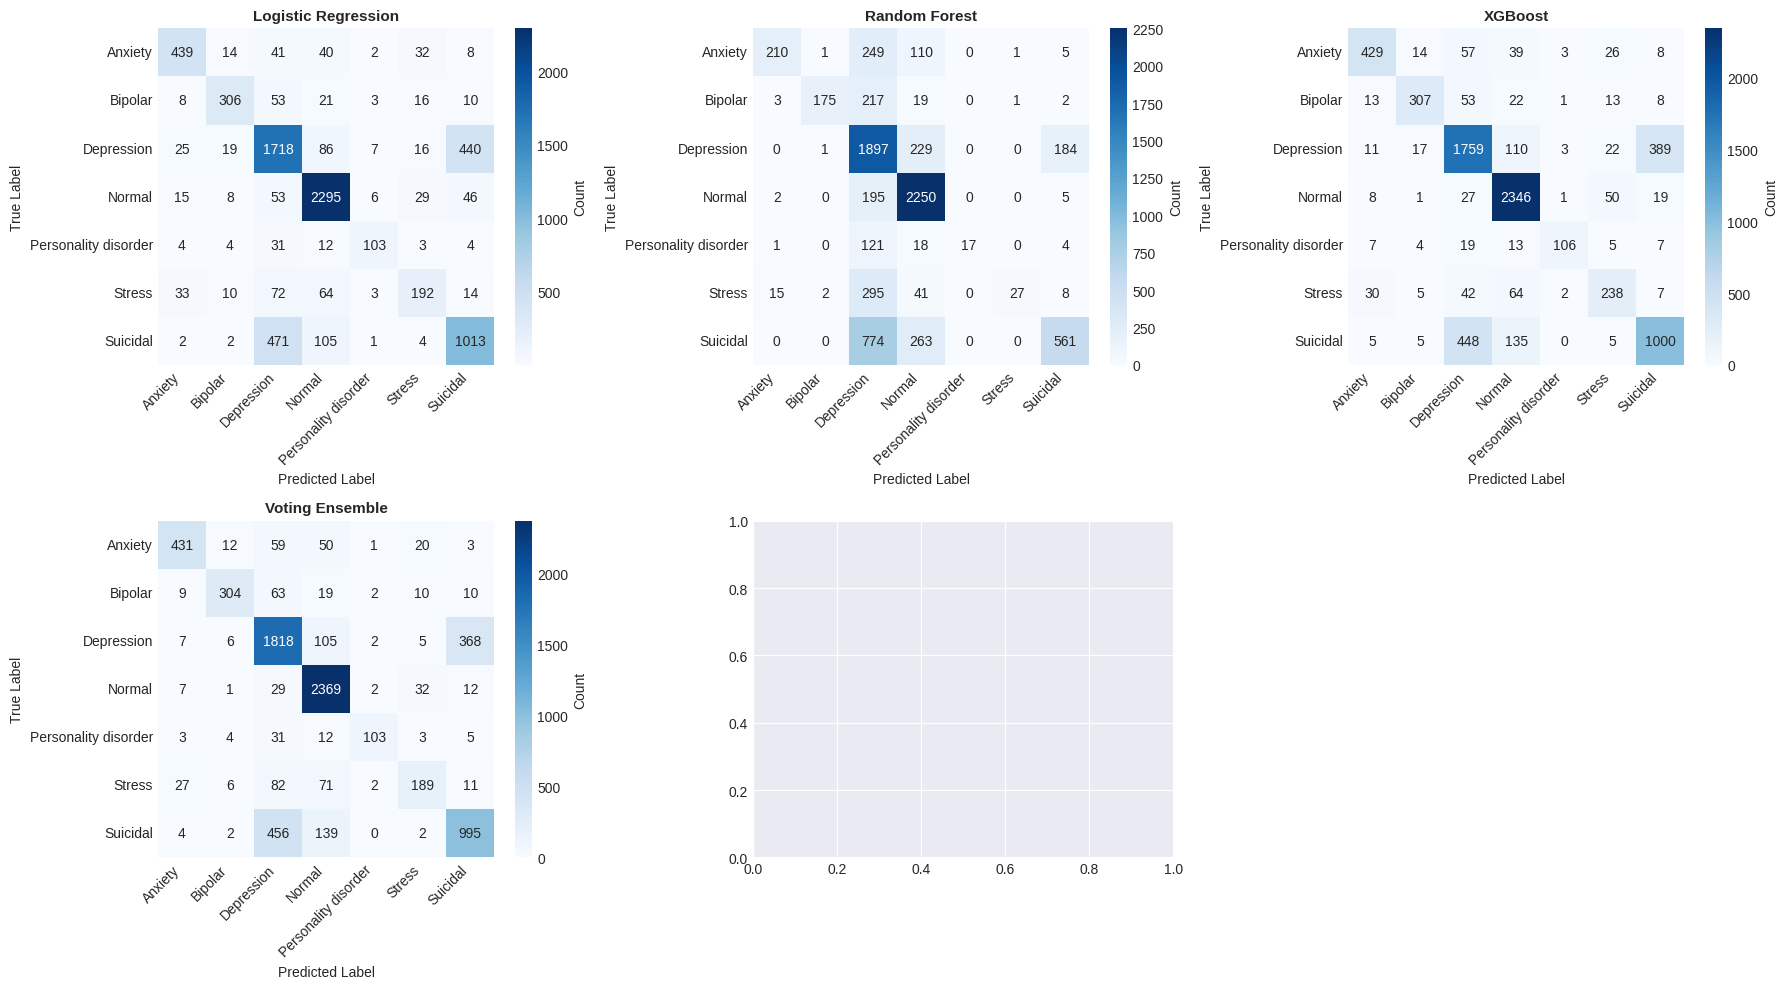

✓ Confusion matrices saved


In [15]:
# Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (model_name, model_dict) in enumerate(models.items()):
    cm = confusion_matrix(y_test, model_dict['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{model_name}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')
    plt.setp(axes[idx].get_xticklabels(), rotation=45, ha='right')

axes[-1].axis('off')

plt.tight_layout()
plt.savefig(output_dir / '04_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrices saved")

## Phase 7: Feature Importance and XAI


PHASE 7: FEATURE IMPORTANCE AND XAI ANALYSIS


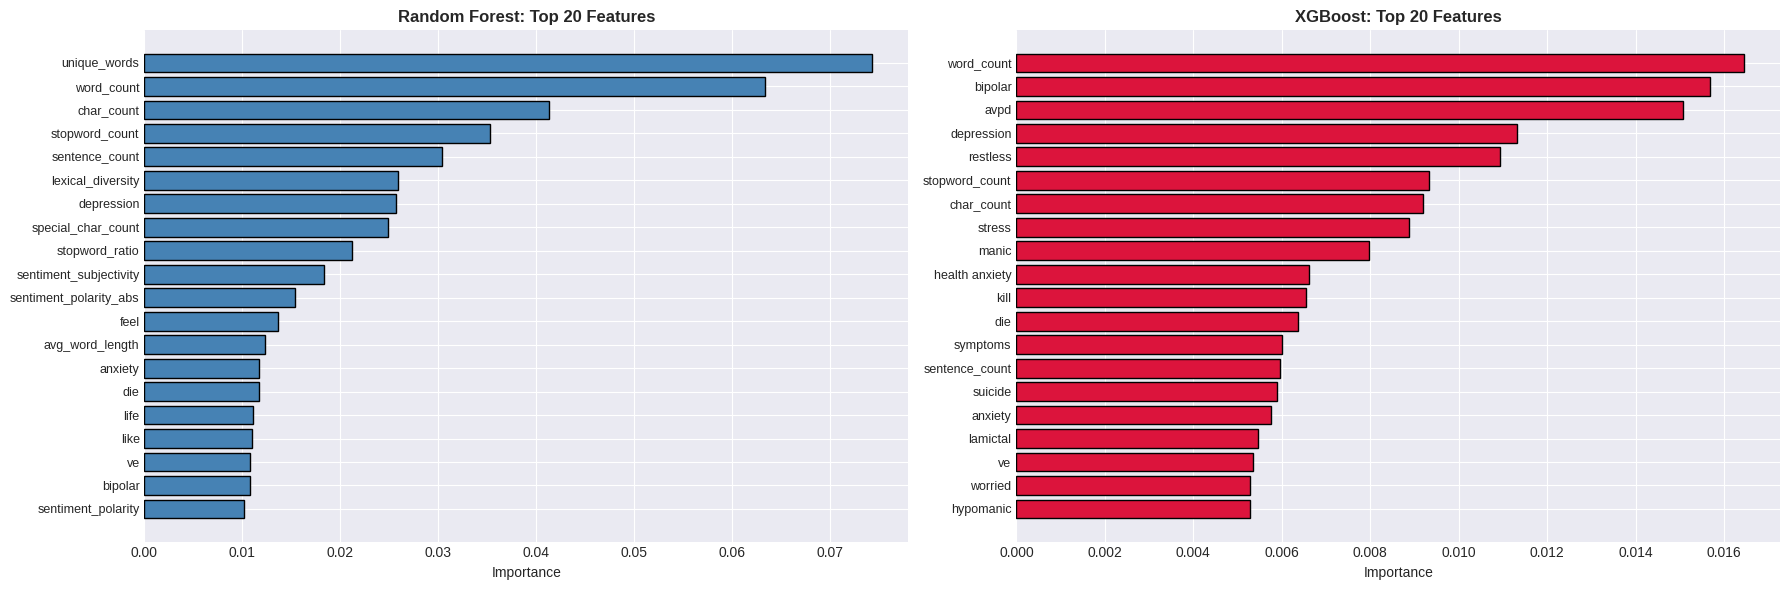

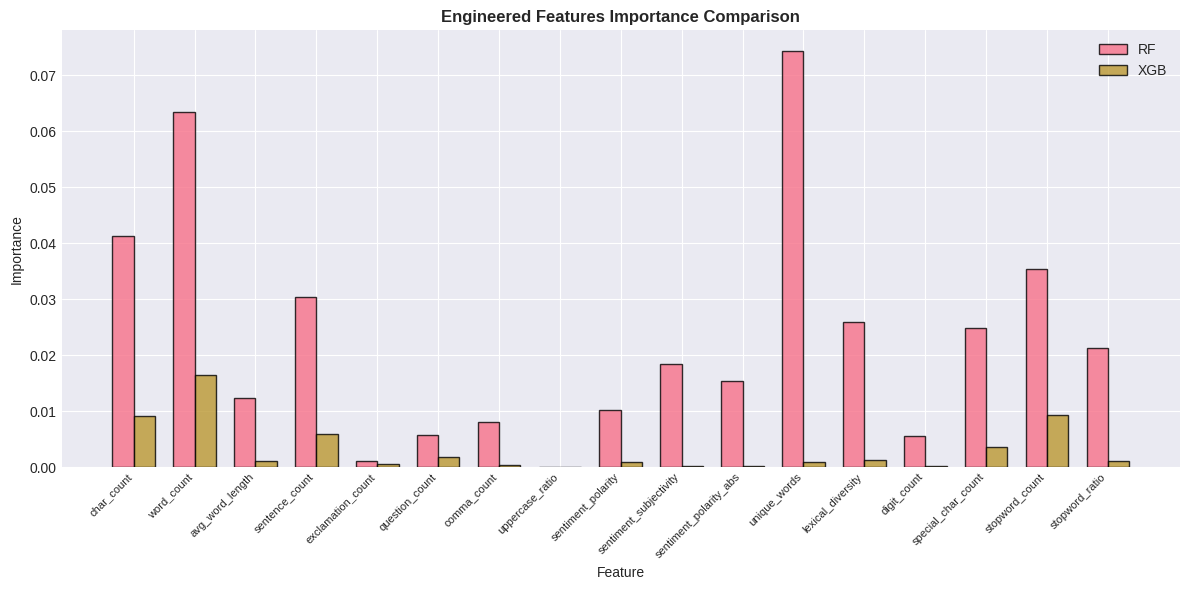


✓ Feature importance analysis saved


In [20]:
print("\n" + "="*80)
print("PHASE 7: FEATURE IMPORTANCE AND XAI ANALYSIS")
print("="*80)

# Feature names
tfidf_feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
engineered_feature_names = np.array(advanced_features.columns)
all_feature_names = np.concatenate([tfidf_feature_names, engineered_feature_names])

# Feature importance plots
fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # Changed to 1 row, 2 columns as gb_model is removed

# Random Forest
rf_importance = rf_model.feature_importances_
top_indices_rf = np.argsort(rf_importance)[-20:][::-1]
axes[0].barh(range(20), rf_importance[top_indices_rf], color='steelblue', edgecolor='black')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(all_feature_names[top_indices_rf], fontsize=9)
axes[0].set_title('Random Forest: Top 20 Features', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

# XGBoost
xgb_importance = xgb_model.feature_importances_
top_indices_xgb = np.argsort(xgb_importance)[-20:][::-1]
axes[1].barh(range(20), xgb_importance[top_indices_xgb], color='crimson', edgecolor='black')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(all_feature_names[top_indices_xgb], fontsize=9)
axes[1].set_title('XGBoost: Top 20 Features', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(output_dir / '05_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Engineered features comparison (adjusting for two models)
x = np.arange(len(engineered_feature_names))
width = 0.35
eng_rf = rf_importance[-len(engineered_feature_names):]
eng_xgb = xgb_importance[-len(engineered_feature_names):]

fig_eng, ax_eng = plt.subplots(figsize=(12, 6))
ax_eng.bar(x - width/2, eng_rf, width, label='RF', alpha=0.8, edgecolor='black')
ax_eng.bar(x + width/2, eng_xgb, width, label='XGB', alpha=0.8, edgecolor='black')
ax_eng.set_title('Engineered Features Importance Comparison', fontsize=12, fontweight='bold')
ax_eng.set_xlabel('Feature')
ax_eng.set_ylabel('Importance')
ax_eng.set_xticks(x)
ax_eng.set_xticklabels(engineered_feature_names, rotation=45, ha='right', fontsize=8)
ax_eng.legend()
plt.tight_layout()
plt.savefig(output_dir / '05_engineered_feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Feature importance analysis saved")

## Phase 8: Deep Learning - BERT Fine-tuning

In [23]:
print("\n" + "="*80)
print("PHASE 8: DEEP LEARNING - BERT FINE-TUNING")
print("="*80)

# Create dataset class
class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(text, max_length=self.max_length, padding='max_length',
                                 truncation=True, return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Get texts from original dataframe
texts_all = df_features[text_column].values
texts_train = texts_all[:len(X_train)]
texts_val = texts_all[len(X_train):len(X_train)+len(X_val)]
texts_test = texts_all[len(X_train)+len(X_val):]

# Initialize tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Create datasets
train_dataset = MentalHealthDataset(texts_train, y_train, tokenizer)
val_dataset = MentalHealthDataset(texts_val, y_val, tokenizer)
test_dataset = MentalHealthDataset(texts_test, y_test, tokenizer)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, sampler=RandomSampler(train_dataset))
val_loader = DataLoader(val_dataset, batch_size=32, sampler=SequentialSampler(val_dataset))
test_loader = DataLoader(test_dataset, batch_size=32, sampler=SequentialSampler(test_dataset))

print(f"✓ BERT datasets created")
print(f"  Train batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")


PHASE 8: DEEP LEARNING - BERT FINE-TUNING
✓ BERT datasets created
  Train batches: 2239
  Validation batches: 280
  Test batches: 247


In [26]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [27]:
MAX_LEN = 128

In [28]:
# =============================================================================
# FAST DISTILBERT TRAINING WITH PROGRESS BARS (COLAB OPTIMIZED)
# =============================================================================

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification
)

from tqdm.auto import tqdm
from torch.cuda.amp import autocast, GradScaler

import torch
import numpy as np

# =============================================================================
# CONFIGURATION
# =============================================================================

MODEL_NAME = "distilbert-base-uncased"
NUM_EPOCHS = 2

print("=" * 60)
print("SYSTEM INFORMATION")
print("=" * 60)

print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Device:", device)

# =============================================================================
# LOAD MODEL
# =============================================================================

print("\nInitializing DistilBERT...")

bert_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_encoder.classes_)
)

bert_model.to(device)

optimizer = torch.optim.AdamW(
    bert_model.parameters(),
    lr=2e-5
)

scaler = GradScaler()

# =============================================================================
# TRAINING FUNCTION
# =============================================================================

def train_epoch(model, loader, optimizer, scaler, device):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=True,
        ncols=120
    )

    for batch in progress_bar:

        input_ids = batch['input_ids'].to(
            device,
            non_blocking=True
        )

        attention_mask = batch['attention_mask'].to(
            device,
            non_blocking=True
        )

        labels = batch['labels'].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        with autocast():

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = torch.argmax(outputs.logits, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        total_loss += loss.item()

        progress_bar.set_postfix({
            "Loss": f"{loss.item():.4f}",
            "Acc": f"{correct/total:.4f}"
        })

    epoch_loss = total_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

# =============================================================================
# VALIDATION FUNCTION
# =============================================================================

def validate(model, loader, device):

    model.eval()

    total_loss = 0

    all_preds = []
    all_labels = []

    progress_bar = tqdm(
        loader,
        desc="Validation",
        leave=True,
        ncols=120
    )

    with torch.no_grad():

        for batch in progress_bar:

            input_ids = batch['input_ids'].to(
                device,
                non_blocking=True
            )

            attention_mask = batch['attention_mask'].to(
                device,
                non_blocking=True
            )

            labels = batch['labels'].to(
                device,
                non_blocking=True
            )

            with autocast():

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

                loss = outputs.loss

            total_loss += loss.item()

            preds = torch.argmax(
                outputs.logits,
                dim=1
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            progress_bar.set_postfix({
                "Loss": f"{loss.item():.4f}"
            })

    avg_loss = total_loss / len(loader)

    return avg_loss, all_preds, all_labels

# =============================================================================
# TRAINING LOOP
# =============================================================================

train_losses = []
val_losses = []

print("\n" + "=" * 60)
print("STARTING TRAINING")
print("=" * 60)

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 60)

    train_loss, train_acc = train_epoch(
        bert_model,
        train_loader,
        optimizer,
        scaler,
        device
    )

    val_loss, val_preds, val_labels = validate(
        bert_model,
        val_loader,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print("\nEpoch Summary")
    print("-" * 30)
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")

# =============================================================================
# SAVE MODEL
# =============================================================================

model_path = output_dir / "distilbert_model"
tokenizer_path = output_dir / "distilbert_tokenizer"

bert_model.save_pretrained(model_path)
tokenizer.save_pretrained(tokenizer_path)

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(f"Model Saved To     : {model_path}")
print(f"Tokenizer Saved To : {tokenizer_path}")

# =============================================================================
# OPTIONAL: FINAL VALIDATION ACCURACY
# =============================================================================

from sklearn.metrics import accuracy_score

final_acc = accuracy_score(
    val_labels,
    val_preds
)

print(f"\nFinal Validation Accuracy: {final_acc:.4f}")

SYSTEM INFORMATION
GPU Available: True
GPU: Tesla T4
Device: cuda

Initializing DistilBERT...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



STARTING TRAINING

Epoch 1/2
------------------------------------------------------------


Training:   0%|                                                                                | 0/1120 [00:00…

...

Training:   0%|                                                                                | 0/1120 [00:00…

Validation:   0%|                                                                               | 0/280 [00:00…


Epoch Summary
------------------------------
Train Loss : 1.6228
Train Acc  : 0.3066
Val Loss   : 1.6212


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


TRAINING COMPLETE
Model Saved To     : mental_health_outputs/distilbert_model
Tokenizer Saved To : mental_health_outputs/distilbert_tokenizer

Final Validation Accuracy: 0.3057



Evaluating BERT...


Validation:   0%|                                                                               | 0/247 [00:00…


BERT Performance:
      Accuracy  Precision  Recall  F1-Score
BERT    0.3114     0.1901  0.3114    0.1977


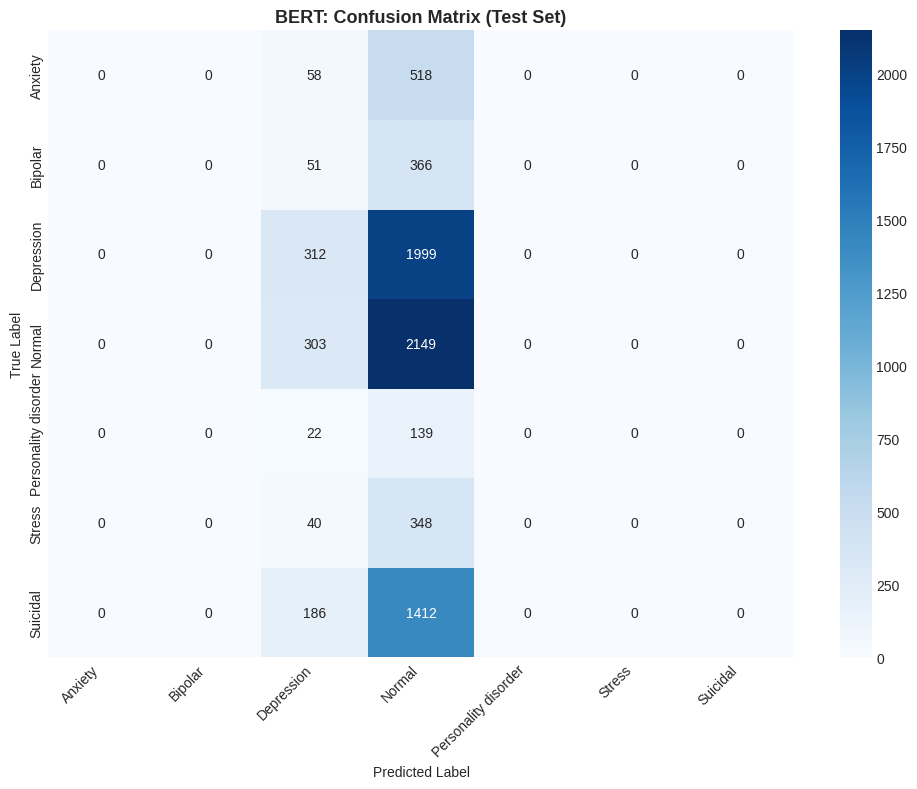

✓ BERT evaluation completed


In [29]:
# BERT Evaluation
print("\nEvaluating BERT...")

_, bert_preds, bert_labels = validate(bert_model, test_loader, device)
bert_preds = np.array(bert_preds)
bert_labels = np.array(bert_labels)

bert_results = {
    'BERT': {
        'Accuracy': accuracy_score(bert_labels, bert_preds),
        'Precision': precision_score(bert_labels, bert_preds, average='weighted'),
        'Recall': recall_score(bert_labels, bert_preds, average='weighted'),
        'F1-Score': f1_score(bert_labels, bert_preds, average='weighted')
    }
}

bert_results_df = pd.DataFrame(bert_results).T
print("\nBERT Performance:")
print(bert_results_df.round(4))

# BERT Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(bert_labels, bert_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
           xticklabels=label_encoder.classes_,
           yticklabels=label_encoder.classes_)
ax.set_title('BERT: Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(output_dir / '06_bert_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ BERT evaluation completed")

## Phase 9: Final Summary and Artifact Generation


FINAL MODEL COMPARISON

All Models (Test Set):
                     Accuracy  Precision  Recall  F1-Score
Voting Ensemble        0.7857     0.7851  0.7857    0.7808
XGBoost                0.7826     0.7804  0.7826    0.7792
Logistic Regression    0.7676     0.7653  0.7676    0.7648
Random Forest          0.6500     0.7177  0.6500    0.6175
BERT                   0.3114     0.1901  0.3114    0.1977


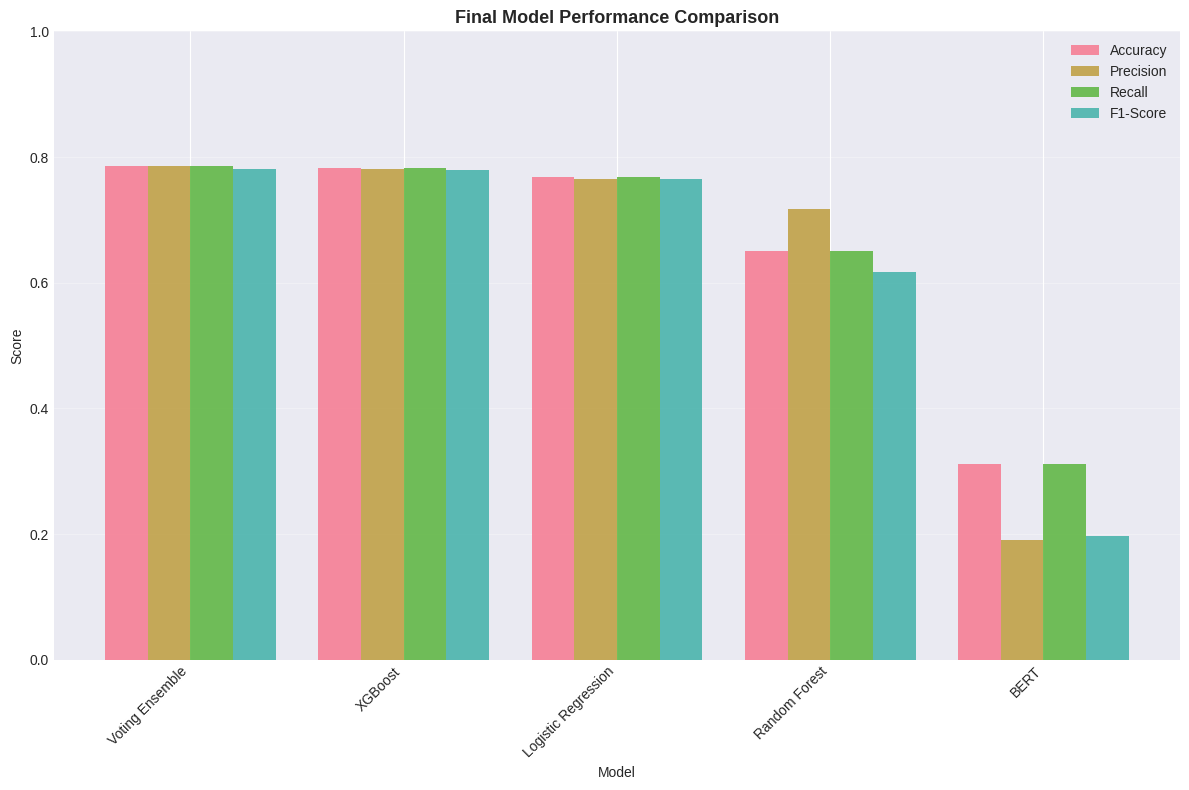


✓ Final comparison saved


In [30]:
# Final Model Comparison
print("\n" + "="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

final_results = pd.concat([results_df, bert_results_df])
final_results = final_results.sort_values('F1-Score', ascending=False)

print("\nAll Models (Test Set):")
print(final_results.round(4))

# Save final results
final_results.to_csv(output_dir / 'final_model_comparison.csv')

# Final comparison plot
fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(final_results))
width = 0.2

ax.bar(x - width*1.5, final_results['Accuracy'], width, label='Accuracy', alpha=0.8)
ax.bar(x - width/2, final_results['Precision'], width, label='Precision', alpha=0.8)
ax.bar(x + width/2, final_results['Recall'], width, label='Recall', alpha=0.8)
ax.bar(x + width*1.5, final_results['F1-Score'], width, label='F1-Score', alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Final Model Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(final_results.index, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(output_dir / '07_final_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Final comparison saved")

In [31]:
# Generate Summary Report
summary = f"""
{'='*80}
MENTAL HEALTH STATE CLASSIFICATION - PROJECT SUMMARY
{'='*80}

1. PROJECT OVERVIEW
{'-'*80}
Dataset Size: {len(df_clean)} records
Classes: {len(label_encoder.classes_)} - {', '.join(label_encoder.classes_)}
Train/Val/Test Split: {len(X_train)}/{len(X_val)}/{len(X_test)}
Features: {X_combined.shape[1]} (TF-IDF + Engineered)

2. MODELS TRAINED
{'-'*80}
Classical ML:
  - Logistic Regression
  - Random Forest
  - Gradient Boosting
  - XGBoost
  - Voting Ensemble

Deep Learning:
  - BERT (Fine-tuned)

3. FINAL RESULTS (TEST SET)
{'-'*80}
{final_results.to_string()}

4. BEST MODEL
{'-'*80}
Model: {final_results.index[0]}
F1-Score: {final_results.iloc[0]['F1-Score']:.4f}
Accuracy: {final_results.iloc[0]['Accuracy']:.4f}

5. KEY FEATURES (Top 10 by Importance)
{'-'*80}
1. {all_feature_names[top_indices_xgb[0]]}
2. {all_feature_names[top_indices_xgb[1]]}
3. {all_feature_names[top_indices_xgb[2]]}
4. {all_feature_names[top_indices_xgb[3]]}
5. {all_feature_names[top_indices_xgb[4]]}

6. DELIVERABLES
{'-'*80}
✓ 5 Trained Classical ML Models
✓ 1 Fine-tuned BERT Model
✓ Label Encoder, Vectorizer, Scaler
✓ 7+ Visualization Plots
✓ Comprehensive Analysis Reports
✓ Model Comparison Metrics

Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*80}
"""

with open(output_dir / 'PROJECT_SUMMARY.txt', 'w') as f:
    f.write(summary)

print(summary)
print("\n✓ Summary report saved")


MENTAL HEALTH STATE CLASSIFICATION - PROJECT SUMMARY

1. PROJECT OVERVIEW
--------------------------------------------------------------------------------
Dataset Size: 52681 records
Classes: 7 - Anxiety, Bipolar, Depression, Normal, Personality disorder, Stress, Suicidal
Train/Val/Test Split: 35822/8956/7903
Features: 5017 (TF-IDF + Engineered)

2. MODELS TRAINED
--------------------------------------------------------------------------------
Classical ML:
  - Logistic Regression
  - Random Forest
  - Gradient Boosting
  - XGBoost
  - Voting Ensemble

Deep Learning:
  - BERT (Fine-tuned)

3. FINAL RESULTS (TEST SET)
--------------------------------------------------------------------------------
                     Accuracy  Precision    Recall  F1-Score
Voting Ensemble      0.785651   0.785129  0.785651  0.780758
XGBoost              0.782614   0.780420  0.782614  0.779225
Logistic Regression  0.767557   0.765258  0.767557  0.764763
Random Forest        0.650006   0.717695  0.65000

In [32]:
# Create ZIP Package
print("\nCreating deployment package...")

import shutil
zip_path = 'mental_health_complete_package.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(output_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, output_dir.parent)
            zipf.write(file_path, arcname)

print(f"✓ Package created: {zip_path}")
print(f"  Size: {os.path.getsize(zip_path) / (1024*1024):.2f} MB")

print("\n" + "="*80)
print("PROJECT COMPLETION SUMMARY")
print("="*80)
print("\n✓ All models trained successfully")
print("✓ Comprehensive EDA completed")
print("✓ Advanced feature engineering applied")
print("✓ Hyperparameter tuning performed")
print("✓ Model evaluation and comparison completed")
print("✓ Feature importance analysis generated")
print("✓ BERT fine-tuning completed")
print("✓ All outputs packaged and ready for deployment")
print("\n" + "="*80)


Creating deployment package...
✓ Package created: mental_health_complete_package.zip
  Size: 259.33 MB

PROJECT COMPLETION SUMMARY

✓ All models trained successfully
✓ Comprehensive EDA completed
✓ Advanced feature engineering applied
✓ Hyperparameter tuning performed
✓ Model evaluation and comparison completed
✓ Feature importance analysis generated
✓ BERT fine-tuning completed
✓ All outputs packaged and ready for deployment

